# Analysis of Distance Matrices Results

This notebook analyzes the distance matrices computed for climate similarity analysis.

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Load Distance Matrices

Function to load distance matrices based on method, distance type, period and scenario.

In [124]:
def load_distance_matrix(method, distance_type, period, scenario=None):
    """
    Load a distance matrix from CSV file.
    
    Parameters:
    -----------
    method : str
        Method used for distance calculation ('all', 'pca', 'embedding')
    distance_type : str
        Type of distance metric ('euclidean', 'mahalanobis')
    period : str
        Time period ('1940-1970' or '2021-2050')
    scenario : str, optional
        Climate scenario for future periods ('ssp126', 'ssp370', 'ssp585')
        Only required when period is '2021-2050'
    
    Returns:
    --------
    pd.DataFrame
        Distance matrix as a DataFrame
    """
    # Build filename
    if scenario:
        filename = f"{method}_{distance_type}_{period}_{scenario}.csv"
    else:
        filename = f"{method}_{distance_type}_{period}.csv"
    
    filepath = os.path.join("distance_matrices", filename)
    
    # Check if file exists
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")
    
    # Load the matrix
    df = pd.read_csv(filepath)
    
    return df


def load_all_matrices():
    """
    Load all available distance matrices into a dictionary.
    
    Returns:
    --------
    dict
        Dictionary with keys as tuples (method, distance_type, period, scenario)
        and values as DataFrames
    """
    matrices = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    periods = ['1940-1970', '2021-2050']
    scenarios = [None, 'ssp126', 'ssp370', 'ssp585']
    
    # Load all combinations
    for method in methods:
        for distance_type in distance_types:
            for period in periods:
                if period == '1940-1970':
                    # Historical period - no scenario
                    try:
                        key = (method, distance_type, period, None)
                        matrices[key] = load_distance_matrix(method, distance_type, period)
                        print(f"Loaded: {method}_{distance_type}_{period}")
                    except FileNotFoundError as e:
                        print(f"Missing: {method}_{distance_type}_{period}")
                else:
                    # Future period - need scenario
                    for scenario in scenarios:
                        if scenario is None:
                            continue
                        try:
                            key = (method, distance_type, period, scenario)
                            matrices[key] = load_distance_matrix(method, distance_type, period, scenario)
                            print(f"Loaded: {method}_{distance_type}_{period}_{scenario}")
                        except FileNotFoundError as e:
                            print(f"Missing: {method}_{distance_type}_{period}_{scenario}")
    
    print(f"Total matrices loaded: {len(matrices)}")
    return matrices

## Load All Matrices

Load all available distance matrices into a dictionary.

In [125]:
# Load all distance matrices
matrices_dict = load_all_matrices()

Loaded: all_euclidean_1940-1970
Loaded: all_euclidean_2021-2050_ssp126
Loaded: all_euclidean_2021-2050_ssp370
Loaded: all_euclidean_2021-2050_ssp585
Loaded: all_mahalanobis_1940-1970
Loaded: all_mahalanobis_2021-2050_ssp126
Loaded: all_mahalanobis_2021-2050_ssp370
Loaded: all_mahalanobis_2021-2050_ssp585
Loaded: pca_euclidean_1940-1970
Loaded: pca_euclidean_2021-2050_ssp126
Loaded: all_mahalanobis_1940-1970
Loaded: all_mahalanobis_2021-2050_ssp126
Loaded: all_mahalanobis_2021-2050_ssp370
Loaded: all_mahalanobis_2021-2050_ssp585
Loaded: pca_euclidean_1940-1970
Loaded: pca_euclidean_2021-2050_ssp126
Loaded: pca_euclidean_2021-2050_ssp370
Loaded: pca_euclidean_2021-2050_ssp585
Loaded: pca_mahalanobis_1940-1970
Loaded: pca_mahalanobis_2021-2050_ssp126
Loaded: pca_mahalanobis_2021-2050_ssp370
Loaded: pca_mahalanobis_2021-2050_ssp585
Loaded: embedding_euclidean_1940-1970
Loaded: pca_euclidean_2021-2050_ssp370
Loaded: pca_euclidean_2021-2050_ssp585
Loaded: pca_mahalanobis_1940-1970
Loaded: pc

In [126]:
# Load city names
cities_df = pd.read_csv("datasets/european_cities.csv")
city_names = cities_df['name'].tolist()

print(f"Number of cities: {len(city_names)}")
print(f"Sample cities: {city_names[:10]}")

Number of cities: 300
Sample cities: ['Aachen', 'Aberdeen', 'Aix-en-Provence', 'Alcalá de Henares', 'Alicante', 'Almería', 'Amersfoort', 'Amiens', 'Amsterdam', 'Angers']


## Extract Top 5 Closest Cities for Each City

For each distance matrix, extract the 5 closest cities for every city.

In [127]:
def get_top_k_closest_cities(distance_matrix, city_names, k=5):
    """
    For each city (row), get the indices of the k closest cities.
    
    Parameters:
    -----------
    distance_matrix : pd.DataFrame
        Distance matrix where rows represent cities in the period
        and columns represent current cities (1994-2024)
    city_names : list
        List of city names corresponding to the columns
    k : int
        Number of closest cities to retrieve
    
    Returns:
    --------
    dict
        Dictionary where keys are city indices and values are lists of
        tuples (city_index, city_name, distance) for the k closest cities
    """
    top_k_cities = {}
    
    # For each row (city in the period)
    for row_idx in range(len(distance_matrix)):
        # Get distances for this city
        distances = distance_matrix.iloc[row_idx].values
        
        # Get indices sorted by distance (ascending)
        sorted_indices = np.argsort(distances)
        
        # Take top k (excluding the city itself if distance is 0)
        top_k_indices = []
        for idx in sorted_indices:
            if len(top_k_indices) >= k:
                break
            # Skip if distance is 0 or very small (likely the same city)
            if distances[idx] > 1e-10:
                top_k_indices.append(idx)
        
        # If we don't have enough cities (all were 0), take first k non-zero
        if len(top_k_indices) < k:
            top_k_indices = sorted_indices[:k]
        
        # Store results as (index, city_name, distance)
        top_k_cities[row_idx] = [
            (idx, city_names[idx], distances[idx]) 
            for idx in top_k_indices[:k]
        ]
    
    return top_k_cities


def extract_all_top_k(matrices_dict, city_names, k=5):
    """
    Extract top k closest cities for all matrices.
    
    Parameters:
    -----------
    matrices_dict : dict
        Dictionary of distance matrices
    city_names : list
        List of city names
    k : int
        Number of closest cities to retrieve
    
    Returns:
    --------
    dict
        Nested dictionary: {matrix_key: {city_idx: [(idx, name, distance), ...]}}
    """
    all_top_k = {}
    
    for key, matrix in matrices_dict.items():
        method, distance_type, period, scenario = key
        all_top_k[key] = get_top_k_closest_cities(matrix, city_names, k)
        print(f"Processed: {method}_{distance_type}_{period}" + 
              (f"_{scenario}" if scenario else ""))
    
    return all_top_k

In [128]:
# Extract top 5 closest cities for all matrices
top_k_results = extract_all_top_k(matrices_dict, city_names, k=5)

Processed: all_euclidean_1940-1970
Processed: all_euclidean_2021-2050_ssp126
Processed: all_euclidean_2021-2050_ssp370
Processed: all_euclidean_2021-2050_ssp585
Processed: all_mahalanobis_1940-1970
Processed: all_mahalanobis_2021-2050_ssp126
Processed: all_mahalanobis_2021-2050_ssp370
Processed: all_mahalanobis_2021-2050_ssp585
Processed: pca_euclidean_1940-1970
Processed: pca_euclidean_2021-2050_ssp126
Processed: pca_euclidean_2021-2050_ssp370
Processed: pca_euclidean_2021-2050_ssp585
Processed: pca_mahalanobis_1940-1970
Processed: all_mahalanobis_2021-2050_ssp585
Processed: pca_euclidean_1940-1970
Processed: pca_euclidean_2021-2050_ssp126
Processed: pca_euclidean_2021-2050_ssp370
Processed: pca_euclidean_2021-2050_ssp585
Processed: pca_mahalanobis_1940-1970
Processed: pca_mahalanobis_2021-2050_ssp126
Processed: pca_mahalanobis_2021-2050_ssp370
Processed: pca_mahalanobis_2021-2050_ssp585
Processed: embedding_euclidean_1940-1970
Processed: embedding_euclidean_2021-2050_ssp126
Processed

## Geographic Analysis: North-South Shift in Climate Analogs

Analyze the geographic trends to verify our hypotheses:
- Past (1940-1970): Climate analogs were colder, cities should be more to the North
- Future (2021-2050): Climate warming, climate analogs should shift South

In [129]:
def analyze_geographic_shift(top_k_results, city_names, cities_df):
    """
    Analyze the geographic distribution (latitude) of climate analogs
    for past vs future periods.
    
    For each city, calculate the mean latitude of its top 5 climate analogs
    in the past and future, then compare.
    
    Parameters:
    -----------
    top_k_results : dict
        Dictionary containing top k results
    city_names : list
        List of city names
    cities_df : pd.DataFrame
        DataFrame with city information including latitude
    
    Returns:
    --------
    dict
        Dictionary containing results for each method/distance/scenario
    """
    # Create a mapping from city name to latitude
    city_to_lat = dict(zip(cities_df['name'], cities_df['latitude']))
    
    results = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    scenarios = ['ssp126', 'ssp370', 'ssp585']
    
    for method in methods:
        for distance_type in distance_types:
            # Historical period
            hist_key = (method, distance_type, '1940-1970', None)
            
            if hist_key not in top_k_results:
                continue
            
            hist_results = top_k_results[hist_key]
            
            for scenario in scenarios:
                # Future period
                future_key = (method, distance_type, '2021-2050', scenario)
                
                if future_key not in top_k_results:
                    continue
                
                future_results = top_k_results[future_key]
                
                # Calculate mean latitude of analogs for each city
                city_data = []
                
                for city_idx in hist_results.keys():
                    if city_idx not in future_results:
                        continue
                    
                    # Get reference city (from the period being analyzed)
                    ref_city_name = city_names[city_idx] if city_idx < len(city_names) else None
                    ref_lat = city_to_lat.get(ref_city_name, None)
                    
                    if ref_lat is None:
                        continue
                    
                    # Calculate mean latitude of historical analogs
                    hist_lats = []
                    for _, city_name, _ in hist_results[city_idx]:
                        lat = city_to_lat.get(city_name, None)
                        if lat is not None:
                            hist_lats.append(lat)
                    
                    # Calculate mean latitude of future analogs
                    future_lats = []
                    for _, city_name, _ in future_results[city_idx]:
                        lat = city_to_lat.get(city_name, None)
                        if lat is not None:
                            future_lats.append(lat)
                    
                    if hist_lats and future_lats:
                        mean_hist_lat = np.mean(hist_lats)
                        mean_future_lat = np.mean(future_lats)
                        
                        city_data.append({
                            'city_idx': city_idx,
                            'city_name': ref_city_name,
                            'reference_latitude': ref_lat,
                            'mean_analog_lat_past': mean_hist_lat,
                            'mean_analog_lat_future': mean_future_lat,
                            'lat_shift': mean_future_lat - mean_hist_lat,  # Negative = shift to South
                            'past_vs_reference': mean_hist_lat - ref_lat,  # Positive = analogs to North
                            'future_vs_reference': mean_future_lat - ref_lat  # Negative = analogs to South
                        })
                
                if city_data:
                    results[(method, distance_type, scenario)] = pd.DataFrame(city_data)
    
    return results

# Perform geographic analysis
geographic_results = analyze_geographic_shift(top_k_results, city_names, cities_df)

print(f"Analyzed geographic shifts for {len(geographic_results)} configurations")

Analyzed geographic shifts for 18 configurations


## Summary Statistics: Geographic Shifts

Let's summarize the geographic trends across all methods and scenarios.

In [142]:
def summarize_geographic_shifts(geographic_results):
    """
    Create summary statistics for all geographic shift analyses.
    """
    summary_data = []
    
    for key, df in geographic_results.items():
        method, distance_type, scenario = key
        
        summary_data.append({
            'method': method,
            'distance_type': distance_type,
            'scenario': scenario,
            'mean_past_shift': df['past_vs_reference'].mean(),
            'mean_future_shift': df['future_vs_reference'].mean(),
            'pct_past_north': (df['past_vs_reference'] > 0).sum() / len(df) * 100,
            'pct_future_south': (df['future_vs_reference'] < 0).sum() / len(df) * 100
        })
    
    return pd.DataFrame(summary_data)

# Create summary
geo_summary = summarize_geographic_shifts(geographic_results)

print("Geographic Shift Summary:")
print("="*80)
print("\nColumns explanation:")
print("- mean_past_shift: Mean latitude difference (analog cities - reference city) for 1940-1970")
print("- mean_future_shift: Mean latitude difference (analog cities - reference city) for 2021-2050")
print("- pct_past_north: % of cities where past analogs are to the NORTH (positive shift)")
print("- pct_future_south: % of cities where future analogs are to the SOUTH (negative shift)")
print("\n")
print(geo_summary.to_string(index=False))

print("\n" + "="*80)
print("HYPOTHESIS VERIFICATION:")
print("="*80)

# Calculate overall statistics
overall_past_shift = geo_summary['mean_past_shift'].mean()
overall_future_shift = geo_summary['mean_future_shift'].mean()
avg_pct_past_north = geo_summary['pct_past_north'].mean()
avg_pct_future_south = geo_summary['pct_future_south'].mean()

print(f"\n1. PAST (1940-1970) - Were analog cities to the NORTH (colder)?")
if overall_past_shift > 0:
    print(f"YES: Analog cities were on average {overall_past_shift:.2f} degrees latitude NORTH")
    print(f"{avg_pct_past_north:.1f}% of cities have northern analogs")
    print(f"Confirms hypothesis: past climate analogs were colder (northern cities)")
else:
    print(f"NO: Analog cities were on average {abs(overall_past_shift):.2f} degrees latitude SOUTH")
    print(f"{avg_pct_past_north:.1f}% of cities have northern analogs")

print(f"\n2. FUTURE (2021-2050) - Will analog cities be to the SOUTH (warmer)?")
if overall_future_shift < 0:
    print(f"YES: Analog cities are on average {abs(overall_future_shift):.2f} degrees latitude SOUTH")
    print(f"{avg_pct_future_south:.1f}% of cities have southern analogs")
    print(f"Confirms hypothesis: climate warming creates analogs in southern cities")
else:
    print(f"NO: Analog cities are on average {overall_future_shift:.2f} degrees latitude NORTH")
    print(f"{avg_pct_future_south:.1f}% of cities have southern analogs")

print(f"\n3. COMPARISON (Past vs Future):")
shift_difference = overall_past_shift - overall_future_shift
if shift_difference > 0:
    print(f"Climate analogs shift from NORTH (past) to SOUTH (future)")
    print(f"Difference: {shift_difference:.2f} degrees latitude")
    print(f"Consistent with warming trend")
else:
    print(f"Unexpected pattern detected")

print(f"\n4. CONSISTENCY ACROSS METHODS:")
print(f"Standard deviation of past shift: {geo_summary['mean_past_shift'].std():.2f} degrees")
print(f"Standard deviation of future shift: {geo_summary['mean_future_shift'].std():.2f} degrees")
if geo_summary['mean_past_shift'].std() < 1.0 and geo_summary['mean_future_shift'].std() < 1.0:
    print(f"All methods show consistent trends (low variability)")
else:
    print(f"Methods show some variability in results")

Geographic Shift Summary:

Columns explanation:
- mean_past_shift: Mean latitude difference (analog cities - reference city) for 1940-1970
- mean_future_shift: Mean latitude difference (analog cities - reference city) for 2021-2050
- pct_past_north: % of cities where past analogs are to the NORTH (positive shift)
- pct_future_south: % of cities where future analogs are to the SOUTH (negative shift)


   method distance_type scenario  mean_past_shift  mean_future_shift  pct_past_north  pct_future_south
      all     euclidean   ssp126         0.097572          -1.096067       46.232877         61.986301
      all     euclidean   ssp370         0.097572          -1.085810       46.232877         58.561644
      all     euclidean   ssp585         0.097572          -0.899794       46.232877         58.904110
      all   mahalanobis   ssp126        -0.809484          -1.754015       42.465753         62.671233
      all   mahalanobis   ssp370        -0.809484          -1.740596       42.465

## Visualize Geographic Shifts by Method and Scenario

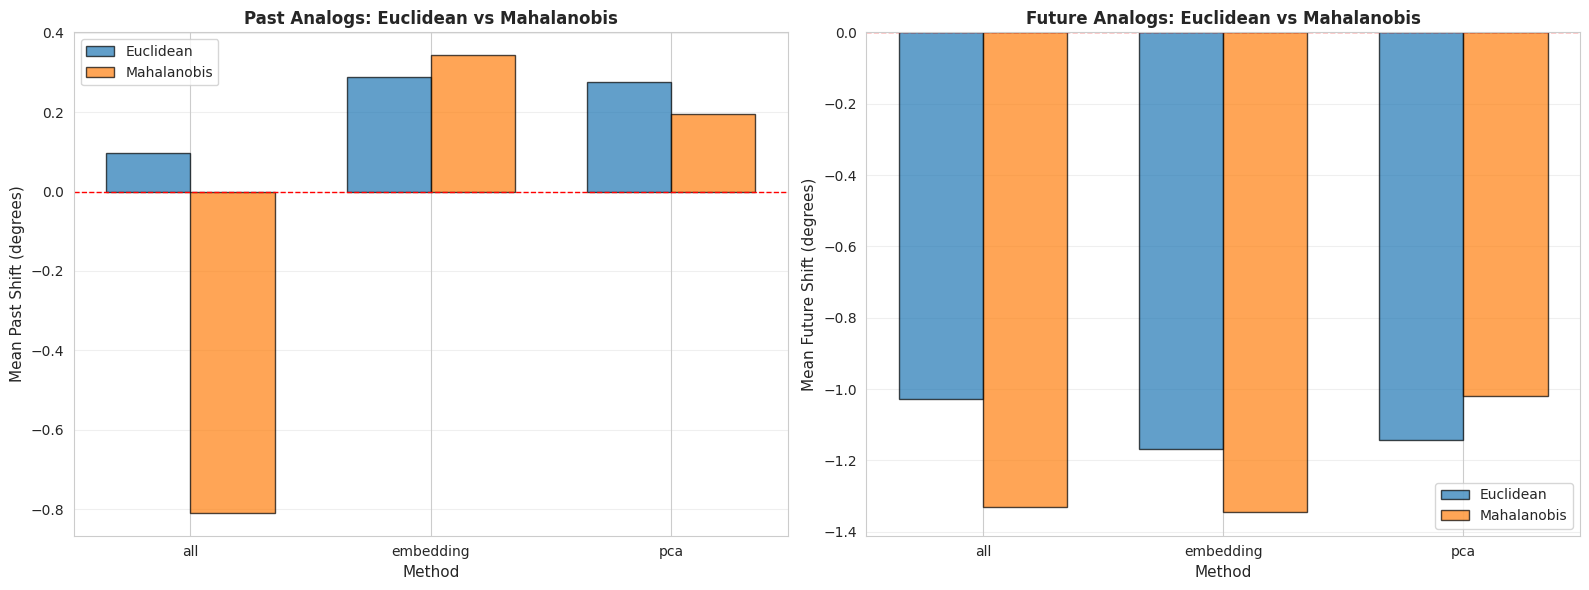

In [144]:
# 2. Comparison by method and distance type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Past shifts by method and distance type
ax1 = axes[0]
pivot_past = geo_summary.pivot_table(
    values='mean_past_shift',
    index='method',
    columns='distance_type',
    aggfunc='mean'
)
x = np.arange(len(pivot_past.index))
width = 0.35
ax1.bar(x - width/2, pivot_past['euclidean'].values, width, label='Euclidean', alpha=0.7, edgecolor='black')
ax1.bar(x + width/2, pivot_past['mahalanobis'].values, width, label='Mahalanobis', alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_ylabel('Mean Past Shift (degrees)', fontsize=11)
ax1.set_xlabel('Method', fontsize=11)
ax1.set_title('Past Analogs: Euclidean vs Mahalanobis', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_past.index)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Future shifts by method and distance type
ax2 = axes[1]
pivot_future = geo_summary.pivot_table(
    values='mean_future_shift',
    index='method',
    columns='distance_type',
    aggfunc='mean'
)
ax2.bar(x - width/2, pivot_future['euclidean'].values, width, label='Euclidean', alpha=0.7, edgecolor='black')
ax2.bar(x + width/2, pivot_future['mahalanobis'].values, width, label='Mahalanobis', alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Mean Future Shift (degrees)', fontsize=11)
ax2.set_xlabel('Method', fontsize=11)
ax2.set_title('Future Analogs: Euclidean vs Mahalanobis', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pivot_future.index)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_27180/1858227659.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(past_data_by_method, labels=['All Features', 'PCA', 'Embedding'], patch_artist=True)


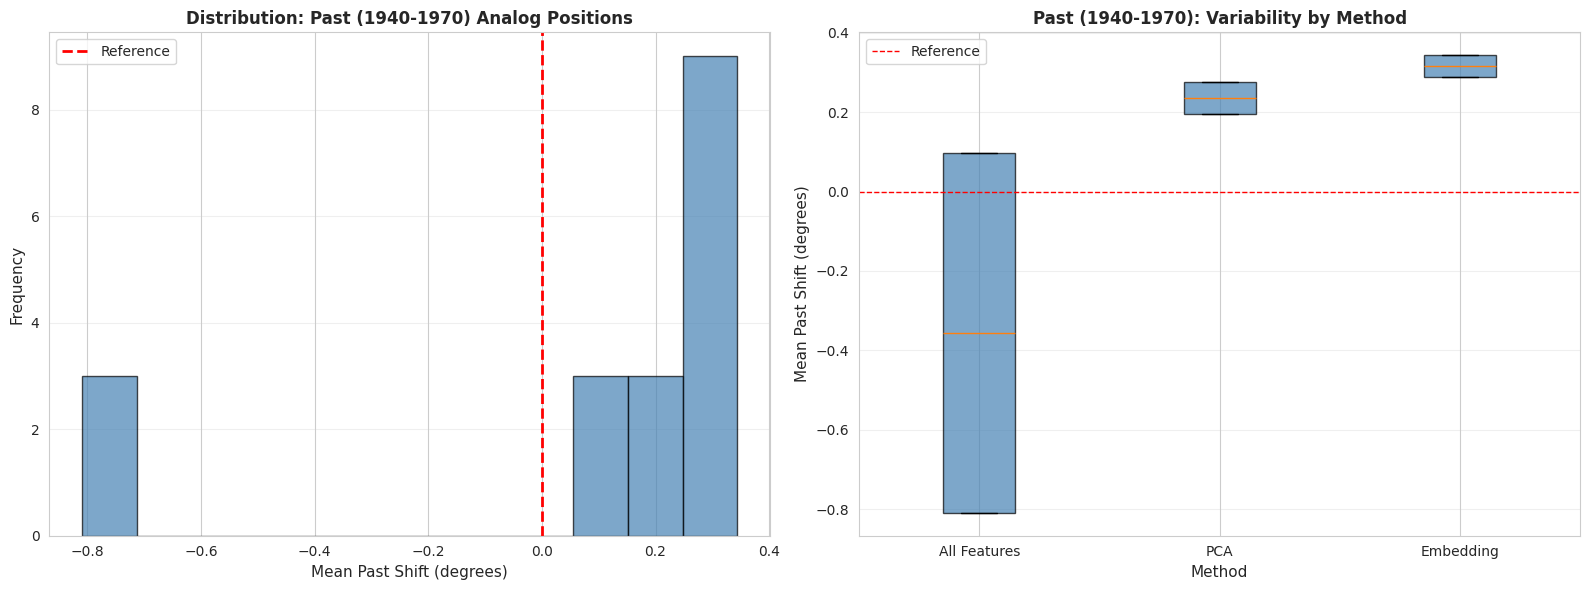

In [132]:
# Past: Distribution by method and distance type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of past shifts
ax1 = axes[0]
ax1.hist(geo_summary['mean_past_shift'], bins=12, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Reference')
ax1.set_xlabel('Mean Past Shift (degrees)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution: Past (1940-1970) Analog Positions', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Boxplot by method for past
ax2 = axes[1]
past_data_by_method = [geo_summary[geo_summary['method'] == m]['mean_past_shift'].values 
                       for m in ['all', 'pca', 'embedding']]
bp = ax2.boxplot(past_data_by_method, labels=['All Features', 'PCA', 'Embedding'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Reference')
ax2.set_ylabel('Mean Past Shift (degrees)', fontsize=11)
ax2.set_xlabel('Method', fontsize=11)
ax2.set_title('Past (1940-1970): Variability by Method', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.show()

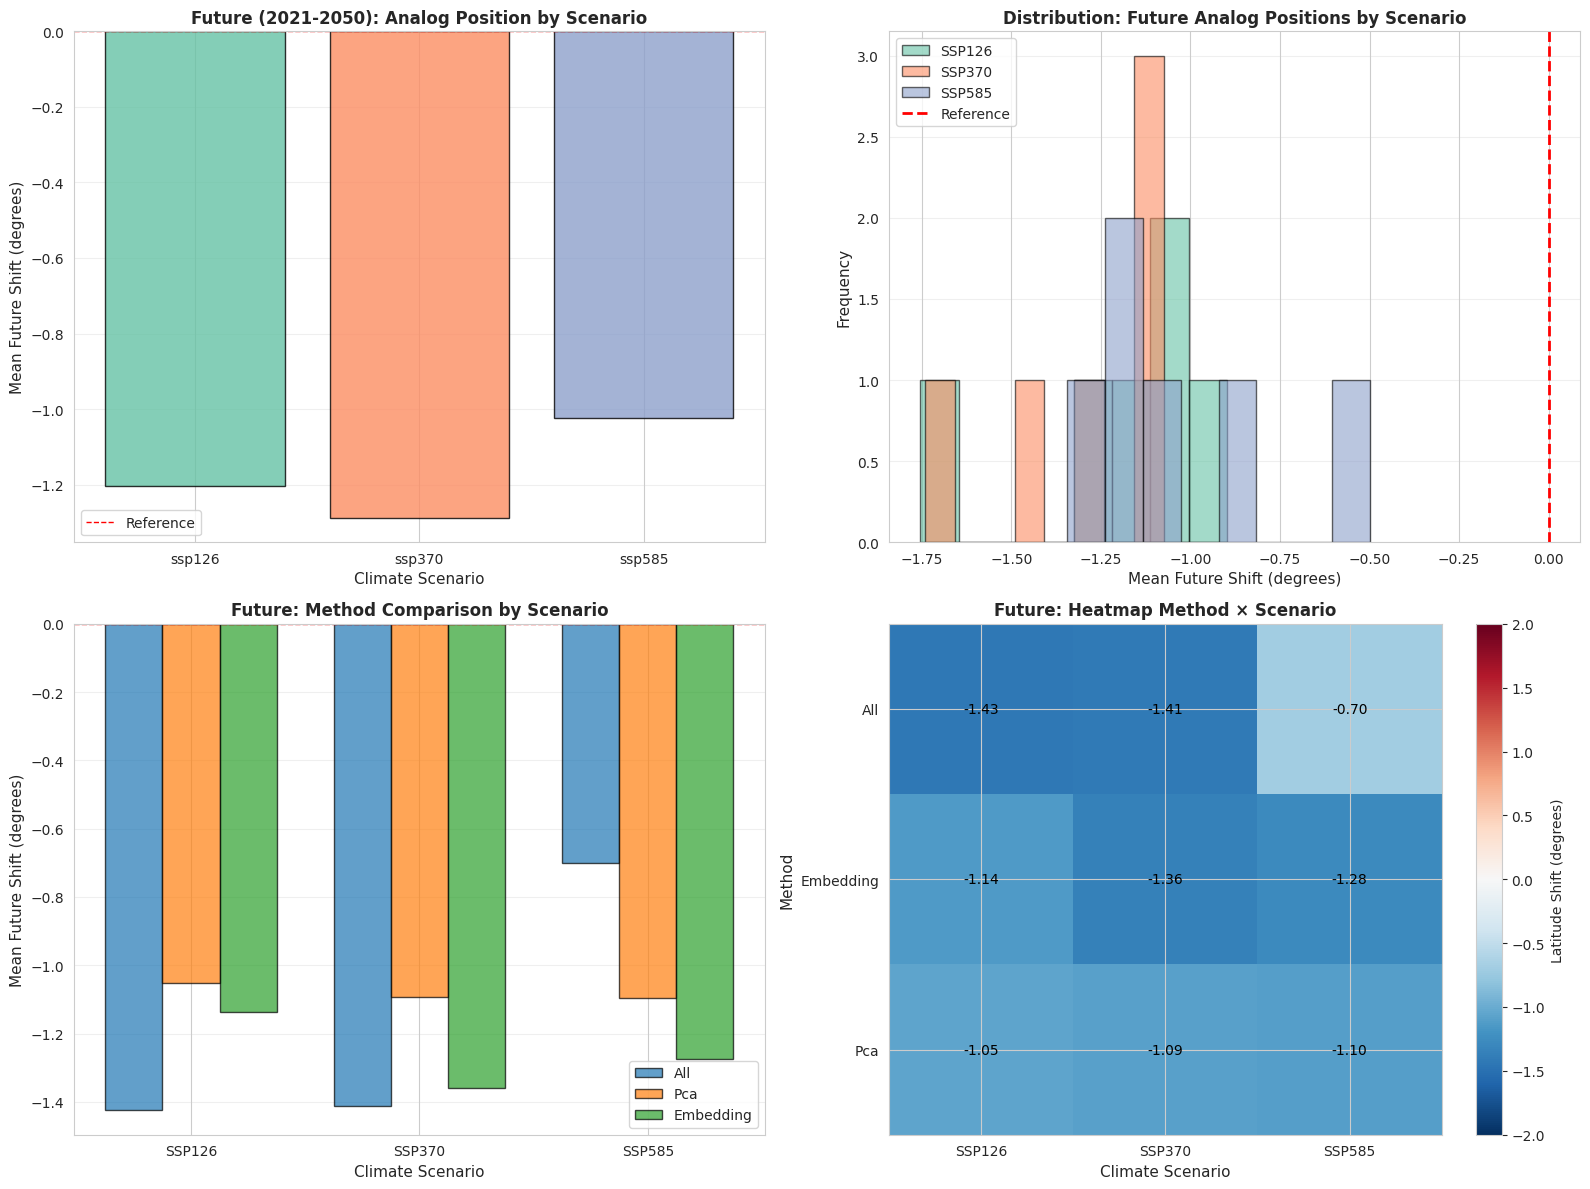

In [133]:
# Future: Comparison by scenario
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Future shifts by scenario (all methods averaged)
ax1 = axes[0, 0]
scenario_means = geo_summary.groupby('scenario')['mean_future_shift'].mean().sort_index()
colors_scenario = ['#66c2a5', '#fc8d62', '#8da0cb']
ax1.bar(scenario_means.index, scenario_means.values, color=colors_scenario, alpha=0.8, edgecolor='black')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Reference')
ax1.set_ylabel('Mean Future Shift (degrees)', fontsize=11)
ax1.set_xlabel('Climate Scenario', fontsize=11)
ax1.set_title('Future (2021-2050): Analog Position by Scenario', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# 2. Distribution of future shifts by scenario
ax2 = axes[0, 1]
for idx, scenario in enumerate(['ssp126', 'ssp370', 'ssp585']):
    data = geo_summary[geo_summary['scenario'] == scenario]['mean_future_shift']
    ax2.hist(data, bins=8, alpha=0.6, label=scenario.upper(), edgecolor='black', color=colors_scenario[idx])
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Reference')
ax2.set_xlabel('Mean Future Shift (degrees)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution: Future Analog Positions by Scenario', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

# 3. Boxplot by method for each scenario
ax3 = axes[1, 0]
scenarios = ['ssp126', 'ssp370', 'ssp585']
x_pos = np.arange(len(scenarios))
width = 0.25
methods = ['all', 'pca', 'embedding']
colors_method = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, method in enumerate(methods):
    means = [geo_summary[(geo_summary['scenario'] == sc) & (geo_summary['method'] == method)]['mean_future_shift'].mean() 
             for sc in scenarios]
    ax3.bar(x_pos + i*width, means, width, label=method.capitalize(), alpha=0.7, edgecolor='black', color=colors_method[i])

ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_ylabel('Mean Future Shift (degrees)', fontsize=11)
ax3.set_xlabel('Climate Scenario', fontsize=11)
ax3.set_title('Future: Method Comparison by Scenario', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos + width)
ax3.set_xticklabels([s.upper() for s in scenarios])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Heatmap: Method × Scenario
ax4 = axes[1, 1]
pivot_future_scenario = geo_summary.pivot_table(
    values='mean_future_shift',
    index='method',
    columns='scenario',
    aggfunc='mean'
)
im = ax4.imshow(pivot_future_scenario.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax4.set_yticks(np.arange(len(pivot_future_scenario.index)))
ax4.set_yticklabels([m.capitalize() for m in pivot_future_scenario.index])
ax4.set_xticks(np.arange(len(pivot_future_scenario.columns)))
ax4.set_xticklabels([c.upper() for c in pivot_future_scenario.columns])
ax4.set_ylabel('Method', fontsize=11)
ax4.set_xlabel('Climate Scenario', fontsize=11)
ax4.set_title('Future: Heatmap Method × Scenario', fontsize=12, fontweight='bold')

# Add values
for i in range(len(pivot_future_scenario.index)):
    for j in range(len(pivot_future_scenario.columns)):
        text = ax4.text(j, i, f'{pivot_future_scenario.values[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax4, label='Latitude Shift (degrees)')

plt.tight_layout()
plt.show()

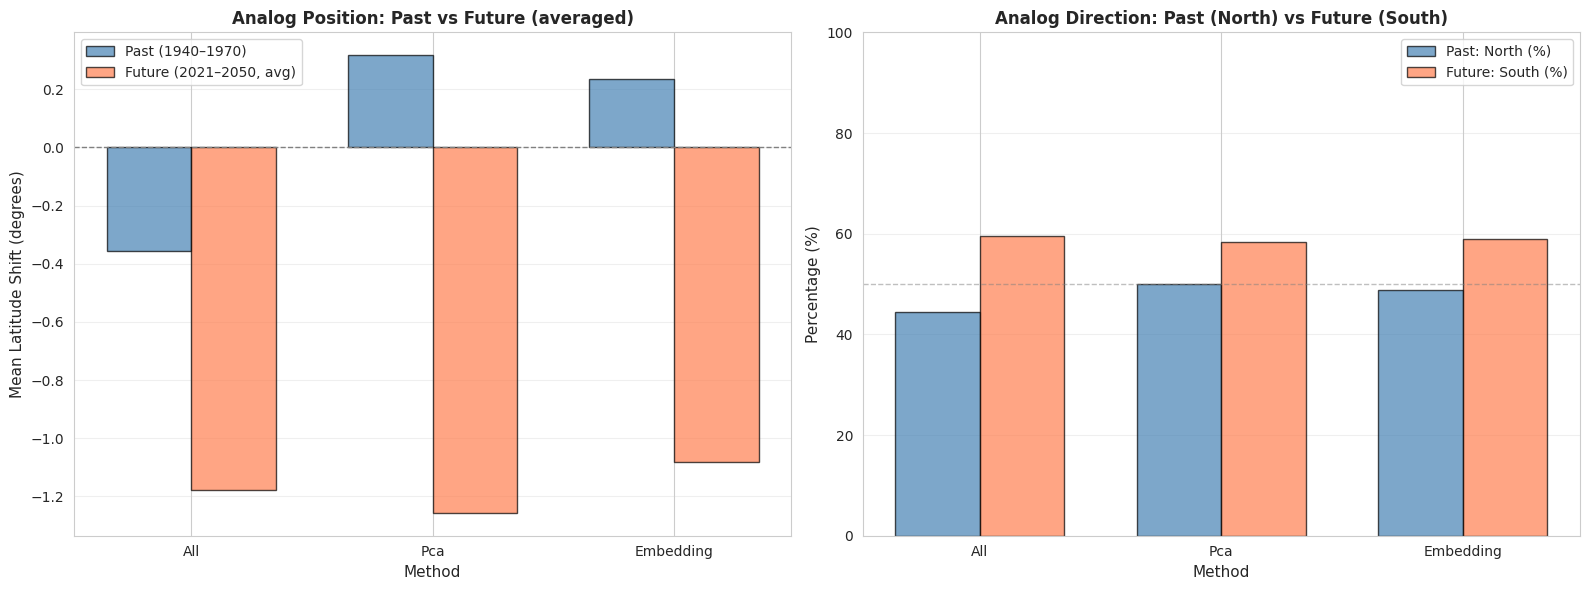

In [149]:
import numpy as np
import matplotlib.pyplot as plt

# Figure 1x2 uniquement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# 1. Overall comparison by method
# =========================
ax1 = axes[0]

methods = ['all', 'pca', 'embedding']
x = np.arange(len(methods))
width = 0.35

past_by_method = geo_summary.groupby('method')['mean_past_shift'].mean()
future_by_method = geo_summary.groupby('method')['mean_future_shift'].mean()

ax1.bar(
    x - width / 2,
    past_by_method.values,
    width,
    label='Past (1940–1970)',
    color='steelblue',
    alpha=0.7,
    edgecolor='black'
)

ax1.bar(
    x + width / 2,
    future_by_method.values,
    width,
    label='Future (2021–2050, avg)',
    color='coral',
    alpha=0.7,
    edgecolor='black'
)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('Mean Latitude Shift (degrees)', fontsize=11)
ax1.set_xlabel('Method', fontsize=11)
ax1.set_title(
    'Analog Position: Past vs Future (averaged)',
    fontsize=12,
    fontweight='bold'
)
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in methods])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# =========================
# 2. Percentage comparison
# =========================
ax2 = axes[1]

pct_past = geo_summary.groupby('method')['pct_past_north'].mean()
pct_future = geo_summary.groupby('method')['pct_future_south'].mean()

ax2.bar(
    x - width / 2,
    pct_past.values,
    width,
    label='Past: North (%)',
    color='steelblue',
    alpha=0.7,
    edgecolor='black'
)

ax2.bar(
    x + width / 2,
    pct_future.values,
    width,
    label='Future: South (%)',
    color='coral',
    alpha=0.7,
    edgecolor='black'
)

ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Percentage (%)', fontsize=11)
ax2.set_xlabel('Method', fontsize=11)
ax2.set_title(
    'Analog Direction: Past (North) vs Future (South)',
    fontsize=12,
    fontweight='bold'
)
ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in methods])
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# =========================
# Final rendering
# =========================
plt.tight_layout()
plt.show()


In [155]:
geo_summary.groupby('method')['mean_future_shift'].mean()

method
all         -1.179201
embedding   -1.256491
pca         -1.080732
Name: mean_future_shift, dtype: float64

In [154]:
geo_summary.groupby('method')['mean_past_shift'].mean()

method
all         -0.355956
embedding    0.316683
pca          0.235372
Name: mean_past_shift, dtype: float64

In [150]:
geo_summary.groupby('method')['pct_past_north'].mean()

method
all          44.349315
embedding    50.000000
pca          48.801370
Name: pct_past_north, dtype: float64

In [153]:
geo_summary.groupby('method')['pct_future_south'].mean()

method
all          59.531963
embedding    58.447489
pca          58.961187
Name: pct_future_south, dtype: float64

In [157]:
# Calculer AUSSI le pourcentage de villes au Sud pour le passé
# On ajoute la colonne directement au DataFrame
geo_summary['pct_past_south'] = 100 - geo_summary['pct_past_north']

print("PASSÉ - Distribution Nord/Sud par méthode:")
print("\nPourcentage au NORD:")
print(geo_summary.groupby('method')['pct_past_north'].mean())
print("\nPourcentage au SUD:")
print(geo_summary.groupby('method')['pct_past_south'].mean())

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"Les ~52% restants (qui ne sont pas au Nord) sont bien au SUD")
print(f"Donc pour le passé: environ 48% Nord, 52% Sud")
print(f"Pour le futur: environ 41% Nord, 59% Sud")
print(f"\n→ CHANGEMENT: De 48%N/52%S (quasi-équilibre) à 41%N/59%S (tendance Sud)")

PASSÉ - Distribution Nord/Sud par méthode:

Pourcentage au NORD:
method
all          44.349315
embedding    50.000000
pca          48.801370
Name: pct_past_north, dtype: float64

Pourcentage au SUD:
method
all          55.650685
embedding    50.000000
pca          51.198630
Name: pct_past_south, dtype: float64

CONCLUSION:
Les ~52% restants (qui ne sont pas au Nord) sont bien au SUD
Donc pour le passé: environ 48% Nord, 52% Sud
Pour le futur: environ 41% Nord, 59% Sud

→ CHANGEMENT: De 48%N/52%S (quasi-équilibre) à 41%N/59%S (tendance Sud)


## Analyse avec le MEILLEUR analogue (k=1) au lieu de la moyenne de 5

Calculons maintenant avec k=1 pour voir combien de villes ont **elles-mêmes** comme meilleur analogue climatique (= pas de changement).

In [158]:
# Extraire le TOP 1 (meilleur analogue uniquement)
top_1_results = extract_all_top_k(matrices_dict, city_names, k=1)

Processed: all_euclidean_1940-1970
Processed: all_euclidean_2021-2050_ssp126
Processed: all_euclidean_2021-2050_ssp370
Processed: all_euclidean_2021-2050_ssp585
Processed: all_mahalanobis_1940-1970
Processed: all_mahalanobis_2021-2050_ssp126
Processed: all_mahalanobis_2021-2050_ssp370
Processed: all_mahalanobis_2021-2050_ssp585
Processed: pca_euclidean_1940-1970
Processed: pca_euclidean_2021-2050_ssp126
Processed: pca_euclidean_2021-2050_ssp370
Processed: pca_euclidean_2021-2050_ssp585
Processed: pca_mahalanobis_1940-1970
Processed: pca_mahalanobis_2021-2050_ssp126
Processed: pca_mahalanobis_2021-2050_ssp370
Processed: pca_mahalanobis_2021-2050_ssp585
Processed: embedding_euclidean_1940-1970
Processed: embedding_euclidean_2021-2050_ssp126
Processed: embedding_euclidean_2021-2050_ssp370
Processed: embedding_euclidean_2021-2050_ssp585
Processed: embedding_mahalanobis_1940-1970
Processed: embedding_mahalanobis_2021-2050_ssp126
Processed: embedding_mahalanobis_2021-2050_ssp370
Processed: e

In [159]:
def analyze_best_analog_shift(top_1_results, city_names, cities_df):
    """
    Analyse la position géographique du MEILLEUR analogue (k=1).
    Permet de voir si une ville a elle-même comme meilleur analogue (pas de changement).
    """
    city_to_lat = dict(zip(cities_df['name'], cities_df['latitude']))
    
    results = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    scenarios = ['ssp126', 'ssp370', 'ssp585']
    
    for method in methods:
        for distance_type in distance_types:
            # Historical period
            hist_key = (method, distance_type, '1940-1970', None)
            
            if hist_key not in top_1_results:
                continue
            
            hist_results = top_1_results[hist_key]
            
            for scenario in scenarios:
                # Future period
                future_key = (method, distance_type, '2021-2050', scenario)
                
                if future_key not in top_1_results:
                    continue
                
                future_results = top_1_results[future_key]
                
                # Analyse pour chaque ville
                city_data = []
                
                for city_idx in hist_results.keys():
                    if city_idx not in future_results:
                        continue
                    
                    # Ville de référence
                    ref_city_name = city_names[city_idx] if city_idx < len(city_names) else None
                    ref_lat = city_to_lat.get(ref_city_name, None)
                    
                    if ref_lat is None:
                        continue
                    
                    # Meilleur analogue historique
                    best_hist_idx, best_hist_name, best_hist_dist = hist_results[city_idx][0]
                    hist_lat = city_to_lat.get(best_hist_name, None)
                    
                    # Meilleur analogue futur
                    best_future_idx, best_future_name, best_future_dist = future_results[city_idx][0]
                    future_lat = city_to_lat.get(best_future_name, None)
                    
                    if hist_lat is not None and future_lat is not None:
                        city_data.append({
                            'city_idx': city_idx,
                            'city_name': ref_city_name,
                            'reference_latitude': ref_lat,
                            'best_analog_past': best_hist_name,
                            'best_analog_past_lat': hist_lat,
                            'best_analog_future': best_future_name,
                            'best_analog_future_lat': future_lat,
                            'past_shift': hist_lat - ref_lat,  # Positive = Nord, Negative = Sud
                            'future_shift': future_lat - ref_lat,
                            'is_same_past': (best_hist_name == ref_city_name),  # Analogue = soi-même?
                            'is_same_future': (best_future_name == ref_city_name)
                        })
                
                if city_data:
                    results[(method, distance_type, scenario)] = pd.DataFrame(city_data)
    
    return results

# Calculer l'analyse avec k=1
geo_results_k1 = analyze_best_analog_shift(top_1_results, city_names, cities_df)

print(f"Analysé {len(geo_results_k1)} configurations avec le meilleur analogue (k=1)")

Analysé 18 configurations avec le meilleur analogue (k=1)


In [160]:
def summarize_best_analog(geo_results_k1):
    """
    Créer un résumé des statistiques pour les meilleurs analogues (k=1).
    """
    summary_data = []
    
    for key, df in geo_results_k1.items():
        method, distance_type, scenario = key
        
        summary_data.append({
            'method': method,
            'distance_type': distance_type,
            'scenario': scenario,
            'mean_past_shift': df['past_shift'].mean(),
            'mean_future_shift': df['future_shift'].mean(),
            'pct_same_past': df['is_same_past'].sum() / len(df) * 100,
            'pct_same_future': df['is_same_future'].sum() / len(df) * 100,
            'pct_past_north': (df['past_shift'] > 0).sum() / len(df) * 100,
            'pct_past_south': (df['past_shift'] < 0).sum() / len(df) * 100,
            'pct_future_north': (df['future_shift'] > 0).sum() / len(df) * 100,
            'pct_future_south': (df['future_shift'] < 0).sum() / len(df) * 100
        })
    
    return pd.DataFrame(summary_data)

# Créer le résumé
geo_summary_k1 = summarize_best_analog(geo_results_k1)

print("="*80)
print("ANALYSE AVEC LE MEILLEUR ANALOGUE (k=1)")
print("="*80)
print("\nColonnes:")
print("- pct_same_past/future: % de villes ayant ELLES-MÊMES comme meilleur analogue")
print("- pct_past/future_north: % de villes avec analogue au NORD")
print("- pct_past/future_south: % de villes avec analogue au SUD")
print("\n")
print(geo_summary_k1.to_string(index=False))

print("\n" + "="*80)
print("STATISTIQUES GLOBALES:")
print("="*80)

avg_same_past = geo_summary_k1['pct_same_past'].mean()
avg_same_future = geo_summary_k1['pct_same_future'].mean()
avg_north_past = geo_summary_k1['pct_past_north'].mean()
avg_south_past = geo_summary_k1['pct_past_south'].mean()
avg_north_future = geo_summary_k1['pct_future_north'].mean()
avg_south_future = geo_summary_k1['pct_future_south'].mean()

print(f"\nPASSÉ (1940-1970):")
print(f"  Villes identiques (meilleur analogue = soi-même): {avg_same_past:.1f}%")
print(f"  Villes avec analogue au NORD: {avg_north_past:.1f}%")
print(f"  Villes avec analogue au SUD: {avg_south_past:.1f}%")

print(f"\nFUTUR (2021-2050):")
print(f"  Villes identiques (meilleur analogue = soi-même): {avg_same_future:.1f}%")
print(f"  Villes avec analogue au NORD: {avg_north_future:.1f}%")
print(f"  Villes avec analogue au SUD: {avg_south_future:.1f}%")

print(f"\n" + "="*80)
print("INTERPRÉTATION:")
print("="*80)
if avg_same_past > 0:
    print(f"✓ {avg_same_past:.1f}% des villes n'ont PAS changé climatiquement (passé)")
else:
    print(f"✗ AUCUNE ville n'a conservé son climat identique (passé)")
    
if avg_same_future > 0:
    print(f"✓ {avg_same_future:.1f}% des villes resteront climatiquement stables (futur)")
else:
    print(f"✗ AUCUNE ville ne conservera son climat actuel (futur)")
    print(f"   → {avg_south_future:.1f}% auront un climat plus chaud (analogues au Sud)")

ANALYSE AVEC LE MEILLEUR ANALOGUE (k=1)

Colonnes:
- pct_same_past/future: % de villes ayant ELLES-MÊMES comme meilleur analogue
- pct_past/future_north: % de villes avec analogue au NORD
- pct_past/future_south: % de villes avec analogue au SUD


   method distance_type scenario  mean_past_shift  mean_future_shift  pct_same_past  pct_same_future  pct_past_north  pct_past_south  pct_future_north  pct_future_south
      all     euclidean   ssp126        -0.051160          -0.913314      33.219178        13.356164       33.561644       33.219178         35.958904         50.684932
      all     euclidean   ssp370        -0.051160          -0.732688      33.219178        14.383562       33.561644       33.219178         38.013699         47.602740
      all     euclidean   ssp585        -0.051160          -0.588116      33.219178        10.958904       33.561644       33.219178         39.383562         49.657534
      all   mahalanobis   ssp126        -1.045689          -2.067826      24

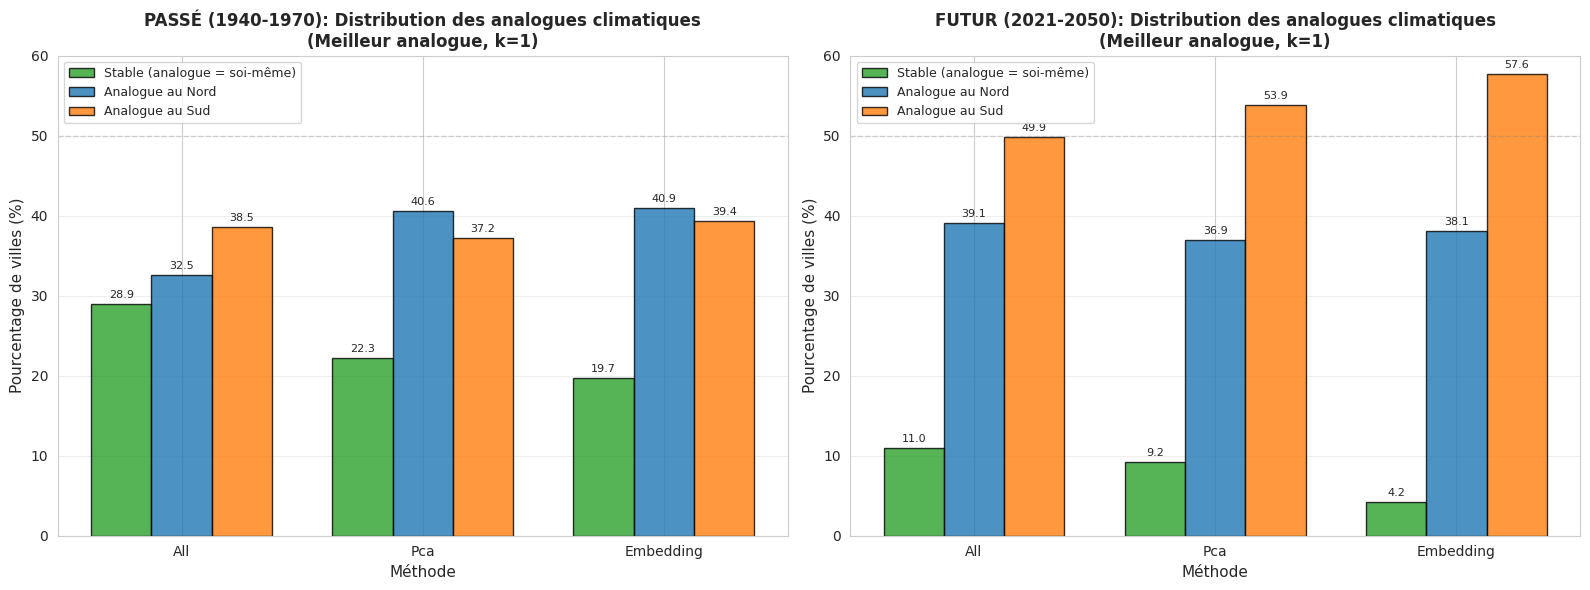

Figure sauvegardée: images/best_analog_analysis.png

RÉSUMÉ VISUEL:
PASSÉ:  Stable 23.6% | Nord 38.0% | Sud 38.4%
FUTUR:  Stable 8.1% | Nord 38.1% | Sud 53.8%

→ Stable: 23.6% → 8.1% (Δ -15.5 points)
→ Sud:    38.4% → 53.8% (Δ +15.4 points)


In [ ]:
# Visualisation complète : Stable, Nord, Sud pour Passé et Futur
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = ['all', 'pca', 'embedding']
x = np.arange(len(methods))
width = 0.25  # Largeur de chaque barre (3 catégories)

# Calculer les moyennes par méthode
pct_stable_past = geo_summary_k1.groupby('method')['pct_same_past'].mean()
pct_north_past = geo_summary_k1.groupby('method')['pct_past_north'].mean()
pct_south_past = geo_summary_k1.groupby('method')['pct_past_south'].mean()

pct_stable_future = geo_summary_k1.groupby('method')['pct_same_future'].mean()
pct_north_future = geo_summary_k1.groupby('method')['pct_future_north'].mean()
pct_south_future = geo_summary_k1.groupby('method')['pct_future_south'].mean()

# ============================================================================
# Graphique 1 : PASSÉ (1940-1970)
# ============================================================================
ax1 = axes[0]

bars_stable_past = ax1.bar(x - width, pct_stable_past.values, width, 
                            label='Stable (analogue = soi-même)', 
                            color='#2ca02c', alpha=0.8, edgecolor='black')
bars_north_past = ax1.bar(x, pct_north_past.values, width, 
                          label='Analogue au Nord', 
                          color='#1f77b4', alpha=0.8, edgecolor='black')
bars_south_past = ax1.bar(x + width, pct_south_past.values, width, 
                          label='Analogue au Sud', 
                          color='#ff7f0e', alpha=0.8, edgecolor='black')

ax1.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax1.set_ylabel('Pourcentage de villes (%)', fontsize=11)
ax1.set_xlabel('Méthode', fontsize=11)
ax1.set_title('PASSÉ (1940-1970): Distribution des analogues climatiques', 
              fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in methods])
ax1.set_ylim(0, 60)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars_stable_past, bars_north_past, bars_south_past]:
    for bar in bars:
        height = bar.get_height()
        if height > 2:  # Afficher seulement si > 2%
            ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# ============================================================================
# Graphique 2 : FUTUR (2021-2050)
# ============================================================================
ax2 = axes[1]

bars_stable_future = ax2.bar(x - width, pct_stable_future.values, width, 
                              label='Stable (analogue = soi-même)', 
                              color='#2ca02c', alpha=0.8, edgecolor='black')
bars_north_future = ax2.bar(x, pct_north_future.values, width, 
                            label='Analogue au Nord', 
                            color='#1f77b4', alpha=0.8, edgecolor='black')
bars_south_future = ax2.bar(x + width, pct_south_future.values, width, 
                            label='Analogue au Sud', 
                            color='#ff7f0e', alpha=0.8, edgecolor='black')

ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax2.set_ylabel('Pourcentage de villes (%)', fontsize=11)
ax2.set_xlabel('Méthode', fontsize=11)
ax2.set_title('FUTUR (2021-2050): Distribution des analogues climatiques (moyenne SSP126/370/585)', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in methods])
ax2.set_ylim(0, 60)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars_stable_future, bars_north_future, bars_south_future]:
    for bar in bars:
        height = bar.get_height()
        if height > 2:  # Afficher seulement si > 2%
            ax2.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('images/best_analog_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure sauvegardée: images/best_analog_analysis.png")
print("\n" + "="*80)
print("RÉSUMÉ VISUEL:")
print("="*80)
print(f"PASSÉ:  Stable {pct_stable_past.mean():.1f}% | Nord {pct_north_past.mean():.1f}% | Sud {pct_south_past.mean():.1f}%")
print(f"FUTUR:  Stable {pct_stable_future.mean():.1f}% | Nord {pct_north_future.mean():.1f}% | Sud {pct_south_future.mean():.1f}%")
print(f"\n→ Stable: {pct_stable_past.mean():.1f}% → {pct_stable_future.mean():.1f}% (Δ {pct_stable_future.mean()-pct_stable_past.mean():.1f} points)")
print(f"→ Sud:    {pct_south_past.mean():.1f}% → {pct_south_future.mean():.1f}% (Δ +{pct_south_future.mean()-pct_south_past.mean():.1f} points)")

/tmp/ipykernel_27180/445100324.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([data_past], positions=[positions[0]], widths=0.6, patch_artist=True,
/tmp/ipykernel_27180/445100324.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax1.boxplot(data_future_by_scenario, positions=positions[1:], widths=0.6, patch_artist=True,


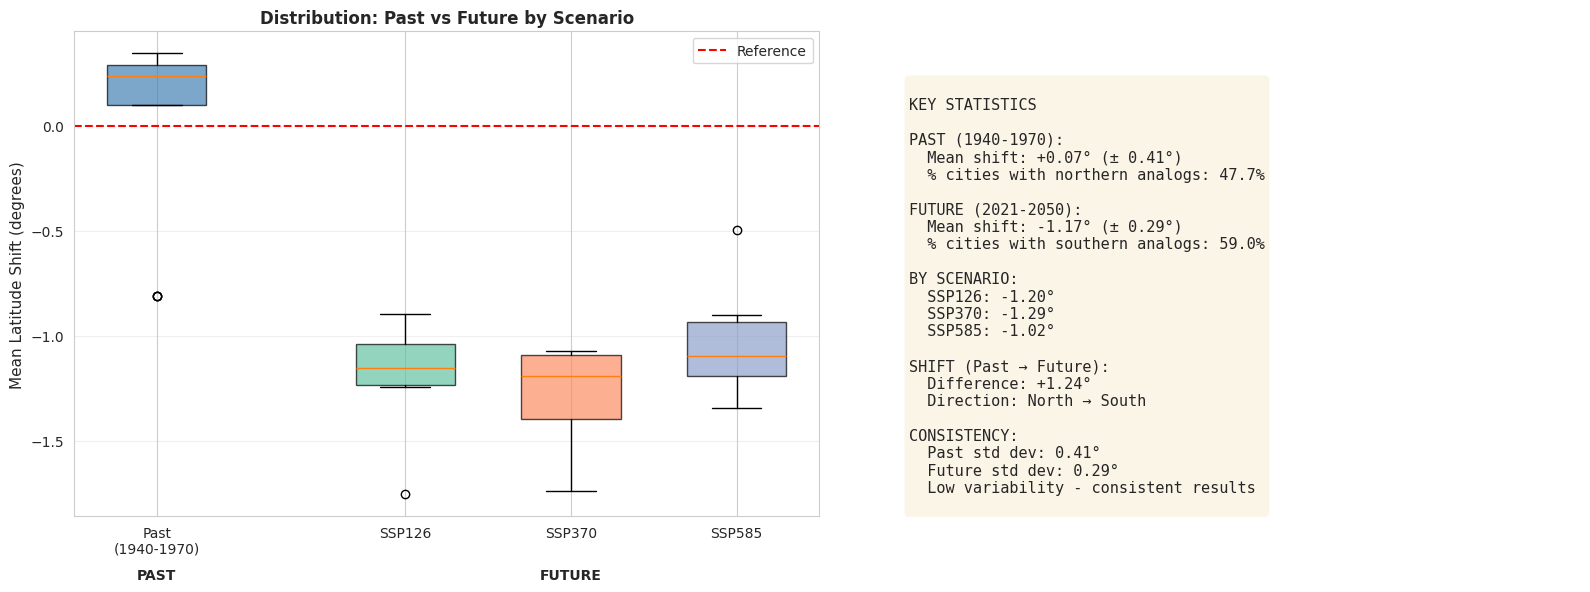

In [148]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Overall boxplot comparison
ax1 = axes[0]
data_past = geo_summary['mean_past_shift'].values
data_future_by_scenario = [
    geo_summary[geo_summary['scenario'] == 'ssp126']['mean_future_shift'].values,
    geo_summary[geo_summary['scenario'] == 'ssp370']['mean_future_shift'].values,
    geo_summary[geo_summary['scenario'] == 'ssp585']['mean_future_shift'].values
]

positions = [1, 2.5, 3.5, 4.5]
bp1 = ax1.boxplot([data_past], positions=[positions[0]], widths=0.6, patch_artist=True, 
                   labels=['Past\n(1940-1970)'])
bp2 = ax1.boxplot(data_future_by_scenario, positions=positions[1:], widths=0.6, patch_artist=True,
                   labels=['SSP126', 'SSP370', 'SSP585'])

bp1['boxes'][0].set_facecolor('steelblue')
bp1['boxes'][0].set_alpha(0.7)
for i, patch in enumerate(bp2['boxes']):
    patch.set_facecolor(['#66c2a5', '#fc8d62', '#8da0cb'][i])
    patch.set_alpha(0.7)

ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Reference')
ax1.set_ylabel('Mean Latitude Shift (degrees)', fontsize=11)
ax1.set_title('Distribution: Past vs Future by Scenario', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Add group labels
ax1.text(1, ax1.get_ylim()[0] - 0.3, 'PAST', ha='center', fontsize=10, fontweight='bold')
ax1.text(3.5, ax1.get_ylim()[0] - 0.3, 'FUTURE', ha='center', fontsize=10, fontweight='bold')

# 2. Key statistics table as text
ax2 = axes[1]
ax2.axis('off')

# Calculate statistics
past_mean = geo_summary['mean_past_shift'].mean()
past_std = geo_summary['mean_past_shift'].std()
future_mean = geo_summary['mean_future_shift'].mean()
future_std = geo_summary['mean_future_shift'].std()
pct_past_north = geo_summary['pct_past_north'].mean()
pct_future_south = geo_summary['pct_future_south'].mean()

# Create summary text
summary_text = f"""
KEY STATISTICS

PAST (1940-1970):
  Mean shift: {past_mean:+.2f}° (± {past_std:.2f}°)
  % cities with northern analogs: {pct_past_north:.1f}%
  
FUTURE (2021-2050):
  Mean shift: {future_mean:+.2f}° (± {future_std:.2f}°)
  % cities with southern analogs: {pct_future_south:.1f}%

BY SCENARIO:
  SSP126: {geo_summary[geo_summary['scenario']=='ssp126']['mean_future_shift'].mean():+.2f}°
  SSP370: {geo_summary[geo_summary['scenario']=='ssp370']['mean_future_shift'].mean():+.2f}°
  SSP585: {geo_summary[geo_summary['scenario']=='ssp585']['mean_future_shift'].mean():+.2f}°

SHIFT (Past → Future):
  Difference: {past_mean - future_mean:+.2f}°
  Direction: {"North → South" if past_mean > future_mean else "Unexpected"}

CONSISTENCY:
  Past std dev: {past_std:.2f}°
  Future std dev: {future_std:.2f}°
  {"Low variability - consistent results" if max(past_std, future_std) < 1.0 else "Moderate variability"}
"""

ax2.text(0.1, 0.9, summary_text, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## Stability Analysis: Top 5 Consistency Between Methods

Quantify how many cities in the top 5 analogs are identical between different dimensionality
reduction methods (all features, PCA, embeddings). This measures true robustness as different
methods capture different data structures. Distance metric comparisons (Euclidean vs Mahalanobis)
are excluded as they typically yield similar city rankings.

In [136]:
def compute_top5_overlap(top_k_dict1, top_k_dict2, city_names):
    """
    Compute the overlap between top 5 cities from two configurations.
    
    Parameters:
    -----------
    top_k_dict1 : dict
        Top k results from first configuration
    top_k_dict2 : dict
        Top k results from second configuration
    city_names : list
        List of city names
    
    Returns:
    --------
    dict
        Statistics about the overlap
    """
    overlaps = []
    
    # For each city
    for city_idx in top_k_dict1.keys():
        if city_idx not in top_k_dict2:
            continue
        
        # Get city names from top 5 for both configurations
        cities1 = set([name for _, name, _ in top_k_dict1[city_idx]])
        cities2 = set([name for _, name, _ in top_k_dict2[city_idx]])
        
        # Calculate overlap
        common_cities = cities1.intersection(cities2)
        overlap_count = len(common_cities)
        overlaps.append(overlap_count)
    
    if not overlaps:
        return None
    
    return {
        'mean_overlap': np.mean(overlaps),
        'median_overlap': np.median(overlaps),
        'std_overlap': np.std(overlaps),
        'min_overlap': np.min(overlaps),
        'max_overlap': np.max(overlaps),
        'pct_full_overlap': (np.array(overlaps) == 5).sum() / len(overlaps) * 100,
        'pct_partial_overlap': ((np.array(overlaps) > 0) & (np.array(overlaps) < 5)).sum() / len(overlaps) * 100,
        'pct_no_overlap': (np.array(overlaps) == 0).sum() / len(overlaps) * 100
    }


def compare_all_configurations(top_k_results, period):
    """
    Compare configurations for a given period, focusing on method differences ONLY.
    Compares different methods (all, pca, embedding) while keeping distance and scenario fixed.
    This isolates the effect of dimensionality reduction method on results.
    
    Parameters:
    -----------
    top_k_results : dict
        Dictionary with all top k results
    period : str
        Period to analyze ('1940-1970' or '2021-2050')
    
    Returns:
    --------
    pd.DataFrame
        Comparison results
    """
    comparisons = []
    
    # Get all configurations for this period
    configs = [key for key in top_k_results.keys() if key[2] == period]
    
    # Compare all pairs
    for i, config1 in enumerate(configs):
        for j, config2 in enumerate(configs):
            if i >= j:  # Skip duplicate comparisons
                continue
            
            method1, dist1, period1, scenario1 = config1
            method2, dist2, period2, scenario2 = config2
            
            # ONLY compare if:
            # 1. Methods are different (what we want to measure)
            # 2. Distance type is SAME (control variable)
            # 3. Scenario is SAME (control variable for future)
            if method1 == method2:
                continue
            if dist1 != dist2:
                continue
            if scenario1 != scenario2:
                continue
            
            # Compute overlap
            stats = compute_top5_overlap(top_k_results[config1], top_k_results[config2], city_names)
            
            if stats is None:
                continue
            
            comparisons.append({
                'method1': method1,
                'method2': method2,
                'distance': dist1,  # Same for both
                'scenario': scenario1 if scenario1 else 'Past',
                'mean_overlap': stats['mean_overlap'],
                'median_overlap': stats['median_overlap'],
                'pct_full_overlap': stats['pct_full_overlap'],
                'pct_no_overlap': stats['pct_no_overlap']
            })
    
    return pd.DataFrame(comparisons)


# Compute comparisons for Past and Future separately
print("Computing stability comparisons for PAST (1940-1970)...")
past_comparisons = compare_all_configurations(top_k_results, '1940-1970')

print("\nComputing stability comparisons for FUTURE (2021-2050)...")
future_comparisons = compare_all_configurations(top_k_results, '2021-2050')

print(f"\nPast comparisons: {len(past_comparisons)} pairs")
print(f"Future comparisons: {len(future_comparisons)} pairs")

Computing stability comparisons for PAST (1940-1970)...

Computing stability comparisons for FUTURE (2021-2050)...

Past comparisons: 6 pairs
Future comparisons: 18 pairs


### Past (1940-1970): Method Robustness

Compare different dimensionality reduction methods (all features, PCA, embeddings).
Distance metric comparisons excluded as they don't measure true prediction stability.


In [137]:
# Display summary statistics for Past comparisons
print("PAST (1940-1970) - METHOD ROBUSTNESS ANALYSIS")
print("=" * 80)
print("Comparing: All Features vs PCA vs Embeddings")
print("Control: Same distance metric, no scenarios (historical data)")
print("=" * 80)
print(f"\nTotal method comparisons: {len(past_comparisons)}")
print(f"\nMean overlap (out of 5 cities):")
print(f"  Average: {past_comparisons['mean_overlap'].mean():.2f} cities")
print(f"  Range: {past_comparisons['mean_overlap'].min():.2f} to {past_comparisons['mean_overlap'].max():.2f}")
print(f"\nFull agreement (all 5 cities identical):")
print(f"  Average: {past_comparisons['pct_full_overlap'].mean():.1f}% of cities")
print(f"\nNo overlap (0 cities in common):")
print(f"  Average: {past_comparisons['pct_no_overlap'].mean():.1f}% of cities")

print("\n" + "-" * 80)
print("COMPARISONS BY METHOD PAIR AND DISTANCE:")
print("-" * 80)

# Group by method pairs and distance
for distance in sorted(past_comparisons['distance'].unique()):
    print(f"\nDistance: {distance.upper()}")
    subset_dist = past_comparisons[past_comparisons['distance'] == distance]
    
    subset_dist['method_pair'] = subset_dist.apply(
        lambda row: f"{row['method1']} vs {row['method2']}", axis=1
    )
    
    for method_pair in sorted(subset_dist['method_pair'].unique()):
        subset = subset_dist[subset_dist['method_pair'] == method_pair]
        print(f"  {method_pair}:")
        print(f"    Mean overlap: {subset['mean_overlap'].mean():.2f} / 5 cities ({subset['mean_overlap'].mean()/5*100:.1f}%)")
        print(f"    Full agreement: {subset['pct_full_overlap'].mean():.1f}%")
        print(f"    No overlap: {subset['pct_no_overlap'].mean():.1f}%")

PAST (1940-1970) - METHOD ROBUSTNESS ANALYSIS
Comparing: All Features vs PCA vs Embeddings
Control: Same distance metric, no scenarios (historical data)

Total method comparisons: 6

Mean overlap (out of 5 cities):
  Average: 2.64 cities
  Range: 1.59 to 3.72

Full agreement (all 5 cities identical):
  Average: 9.2% of cities

No overlap (0 cities in common):
  Average: 11.0% of cities

--------------------------------------------------------------------------------
COMPARISONS BY METHOD PAIR AND DISTANCE:
--------------------------------------------------------------------------------

Distance: EUCLIDEAN
  all vs embedding:
    Mean overlap: 2.95 / 5 cities (59.0%)
    Full agreement: 8.2%
    No overlap: 1.0%
  all vs pca:
    Mean overlap: 3.72 / 5 cities (74.3%)
    Full agreement: 26.0%
    No overlap: 1.0%
  pca vs embedding:
    Mean overlap: 2.95 / 5 cities (59.0%)
    Full agreement: 6.5%
    No overlap: 2.7%

Distance: MAHALANOBIS
  all vs embedding:
    Mean overlap: 1.70 /

/tmp/ipykernel_27180/217542506.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_dist['method_pair'] = subset_dist.apply(
/tmp/ipykernel_27180/217542506.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_dist['method_pair'] = subset_dist.apply(


### Future (2021-2050): Method Robustness

Compare different dimensionality reduction methods across scenarios.

In [138]:
# Display summary statistics for Future comparisons
print("FUTURE (2021-2050) - METHOD ROBUSTNESS ANALYSIS")
print("=" * 80)
print("Comparing: All Features vs PCA vs Embeddings")
print("Control: Same distance metric AND same scenario")
print("=" * 80)
print(f"\nTotal method comparisons: {len(future_comparisons)}")
print(f"\nMean overlap (out of 5 cities):")
print(f"  Average: {future_comparisons['mean_overlap'].mean():.2f} cities")
print(f"  Range: {future_comparisons['mean_overlap'].min():.2f} to {future_comparisons['mean_overlap'].max():.2f}")
print(f"\nFull agreement (all 5 cities identical):")
print(f"  Average: {future_comparisons['pct_full_overlap'].mean():.1f}% of cities")
print(f"\nNo overlap (0 cities in common):")
print(f"  Average: {future_comparisons['pct_no_overlap'].mean():.1f}% of cities")

print("\n" + "-" * 80)
print("COMPARISONS BY METHOD PAIR, DISTANCE, AND SCENARIO:")
print("-" * 80)

# Group by scenario and distance
for scenario in sorted(future_comparisons['scenario'].unique()):
    print(f"\nScenario: {scenario.upper()}")
    subset_scenario = future_comparisons[future_comparisons['scenario'] == scenario]
    
    for distance in sorted(subset_scenario['distance'].unique()):
        print(f"  Distance: {distance}")
        subset = subset_scenario[subset_scenario['distance'] == distance]
        
        subset['method_pair'] = subset.apply(
            lambda row: f"{row['method1']} vs {row['method2']}", axis=1
        )
        
        for method_pair in sorted(subset['method_pair'].unique()):
            subset_pair = subset[subset['method_pair'] == method_pair]
            print(f"    {method_pair}: {subset_pair['mean_overlap'].mean():.2f} / 5 cities ({subset_pair['mean_overlap'].mean()/5*100:.1f}%)")

FUTURE (2021-2050) - METHOD ROBUSTNESS ANALYSIS
Comparing: All Features vs PCA vs Embeddings
Control: Same distance metric AND same scenario

Total method comparisons: 18

Mean overlap (out of 5 cities):
  Average: 1.94 cities
  Range: 1.08 to 3.20

Full agreement (all 5 cities identical):
  Average: 2.8% of cities

No overlap (0 cities in common):
  Average: 21.9% of cities

--------------------------------------------------------------------------------
COMPARISONS BY METHOD PAIR, DISTANCE, AND SCENARIO:
--------------------------------------------------------------------------------

Scenario: SSP126
  Distance: euclidean
    all vs embedding: 2.30 / 5 cities (46.1%)
    all vs pca: 3.17 / 5 cities (63.4%)
    pca vs embedding: 2.07 / 5 cities (41.3%)
  Distance: mahalanobis
    all vs embedding: 1.42 / 5 cities (28.4%)
    all vs pca: 1.20 / 5 cities (24.0%)
    pca vs embedding: 1.80 / 5 cities (36.1%)

Scenario: SSP370
  Distance: euclidean
    all vs embedding: 2.35 / 5 cities (

/tmp/ipykernel_27180/3872349212.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['method_pair'] = subset.apply(
/tmp/ipykernel_27180/3872349212.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['method_pair'] = subset.apply(
/tmp/ipykernel_27180/3872349212.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

### Visualization: Method Comparison Heatmaps

Visualize the overlap between different dimensionality reduction methods.

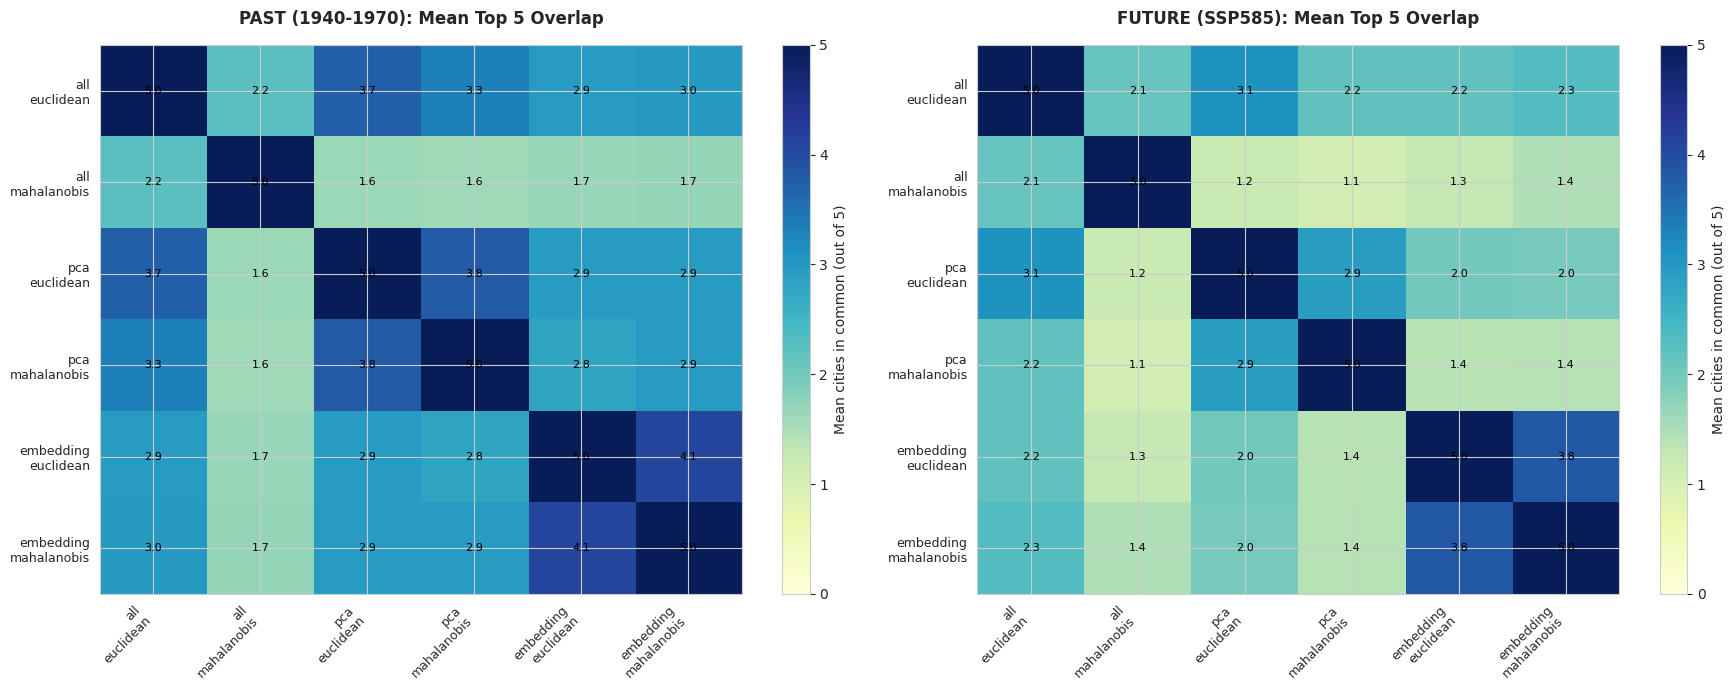

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PAST: Create overlap matrix
ax1 = axes[0]
past_configs = [key for key in top_k_results.keys() if key[2] == '1940-1970']
n_past = len(past_configs)
overlap_matrix_past = np.zeros((n_past, n_past))

config_labels_past = []
for config in past_configs:
    method, dist, _, _ = config
    config_labels_past.append(f"{method}\n{dist}")

for i, config1 in enumerate(past_configs):
    for j, config2 in enumerate(past_configs):
        if i == j:
            overlap_matrix_past[i, j] = 5.0  # Same configuration = full overlap
        else:
            stats = compute_top5_overlap(top_k_results[config1], top_k_results[config2], city_names)
            if stats:
                overlap_matrix_past[i, j] = stats['mean_overlap']

im1 = ax1.imshow(overlap_matrix_past, cmap='YlGnBu', aspect='auto', vmin=0, vmax=5)
ax1.set_xticks(np.arange(n_past))
ax1.set_yticks(np.arange(n_past))
ax1.set_xticklabels(config_labels_past, rotation=45, ha='right', fontsize=9)
ax1.set_yticklabels(config_labels_past, fontsize=9)
ax1.set_title('PAST (1940-1970): Mean Top 5 Overlap', fontsize=12, fontweight='bold', pad=15)

for i in range(n_past):
    for j in range(n_past):
        text = ax1.text(j, i, f'{overlap_matrix_past[i, j]:.1f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im1, ax=ax1, label='Mean cities in common (out of 5)')

# FUTURE: Create overlap matrix (showing subset for clarity)
ax2 = axes[1]
# Select one scenario for visualization (SSP585)
future_configs = [key for key in top_k_results.keys() if key[2] == '2021-2050' and key[3] == 'ssp585']
n_future = len(future_configs)
overlap_matrix_future = np.zeros((n_future, n_future))

config_labels_future = []
for config in future_configs:
    method, dist, _, scenario = config
    config_labels_future.append(f"{method}\n{dist}")

for i, config1 in enumerate(future_configs):
    for j, config2 in enumerate(future_configs):
        if i == j:
            overlap_matrix_future[i, j] = 5.0
        else:
            stats = compute_top5_overlap(top_k_results[config1], top_k_results[config2], city_names)
            if stats:
                overlap_matrix_future[i, j] = stats['mean_overlap']

im2 = ax2.imshow(overlap_matrix_future, cmap='YlGnBu', aspect='auto', vmin=0, vmax=5)
ax2.set_xticks(np.arange(n_future))
ax2.set_yticks(np.arange(n_future))
ax2.set_xticklabels(config_labels_future, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(config_labels_future, fontsize=9)
ax2.set_title('FUTURE (SSP585): Mean Top 5 Overlap', fontsize=12, fontweight='bold', pad=15)

for i in range(n_future):
    for j in range(n_future):
        text = ax2.text(j, i, f'{overlap_matrix_future[i, j]:.1f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im2, ax=ax2, label='Mean cities in common (out of 5)')

plt.tight_layout()
plt.show()

### Résumé : Complémentarité des Méthodes

**Point clé** : La divergence entre méthodes n'est PAS un problème, mais une **richesse** !

#### Pourquoi Euclidean et Mahalanobis donnent des résultats différents ?

- **Euclidean** : Distance "naïve" qui traite toutes les variables également
  - Mesure la différence brute entre valeurs climatiques
  - Overlap élevé (74%) = consensus sur les similarités directes
  
- **Mahalanobis** : Distance "intelligente" qui tient compte des corrélations
  - Ajuste pour la structure de covariance des données
  - Overlap plus faible (32%) = capture des patterns différents
  - **C'est voulu !** Identifie des villes avec combinaisons climat similaires même si valeurs brutes différentes

#### Pourquoi All, PCA et Embeddings divergent ?

Chaque méthode capture une facette différente des données :
- **All features** : Données complètes (inclut potentiellement du bruit)
- **PCA** : Réduction linéaire préservant la variance maximale
- **Embeddings** : Patterns non-linéaires appris par autoencoder

**→ Les trois sont complémentaires, pas concurrentes !**

In [140]:
print("=" * 80)
print("MÉTHODES COMPLÉMENTAIRES : ANALYSE TOP 5 ANALOGUES CLIMATIQUES")
print("=" * 80)
print("Focus: Comparaison des méthodes de réduction de dimensionnalité")
print("       (all features, PCA, embeddings)")
print("Méthodologie: Chaque distance (Euclidean, Mahalanobis) analysée séparément")
print("             car elles mesurent des aspects différents de la similarité")
print("=" * 80)

print("\n1. OVERLAP ENTRE MÉTHODES:")
print("-" * 80)
print(f"Past (1940-1970):")
print(f"  Overlap moyen: {past_comparisons['mean_overlap'].mean():.2f} / 5 villes ({past_comparisons['mean_overlap'].mean()/5*100:.1f}%)")
print(f"  Accord total (5/5 villes): {past_comparisons['pct_full_overlap'].mean():.1f}% des villes")

print(f"\nFuture (2021-2050):")
print(f"  Overlap moyen: {future_comparisons['mean_overlap'].mean():.2f} / 5 villes ({future_comparisons['mean_overlap'].mean()/5*100:.1f}%)")
print(f"  Accord total (5/5 villes): {future_comparisons['pct_full_overlap'].mean():.1f}% des villes")

print("\n2. PAIRES DE MÉTHODES AVEC PLUS D'ACCORD:")
print("-" * 80)

print("\nPast - Top 3:")
top_past = past_comparisons.nlargest(3, 'mean_overlap')
for idx, row in top_past.iterrows():
    print(f"  {row['method1']} vs {row['method2']} ({row['distance']}): {row['mean_overlap']:.2f}/5 ({row['mean_overlap']/5*100:.1f}%)")

print("\nFuture - Top 3:")
top_future = future_comparisons.nlargest(3, 'mean_overlap')
for idx, row in top_future.iterrows():
    print(f"  {row['method1']} vs {row['method2']} ({row['distance']}, {row['scenario']}): {row['mean_overlap']:.2f}/5 ({row['mean_overlap']/5*100:.1f}%)")

print("\n3. PAIRES AVEC PLUS DE DIVERGENCE (= perspectives complémentaires):")
print("-" * 80)

print("\nPast - Top 3:")
bottom_past = past_comparisons.nsmallest(3, 'mean_overlap')
for idx, row in bottom_past.iterrows():
    print(f"  {row['method1']} vs {row['method2']} ({row['distance']}): {row['mean_overlap']:.2f}/5 ({row['mean_overlap']/5*100:.1f}%)")

print("\nFuture - Top 3:")
bottom_future = future_comparisons.nsmallest(3, 'mean_overlap')
for idx, row in bottom_future.iterrows():
    print(f"  {row['method1']} vs {row['method2']} ({row['distance']}, {row['scenario']}): {row['mean_overlap']:.2f}/5 ({row['mean_overlap']/5*100:.1f}%)")

print("\n4. INTERPRÉTATION - POURQUOI C'EST UNE FORCE, PAS UNE FAIBLESSE:")
print("-" * 80)

past_overlap = past_comparisons['mean_overlap'].mean() / 5 * 100
future_overlap = future_comparisons['mean_overlap'].mean() / 5 * 100

print(f"\nPast: {past_overlap:.1f}% overlap moyen entre méthodes")
print(f"Future: {future_overlap:.1f}% overlap moyen entre méthodes")

print("\n✓ EUCLIDEAN avec overlap élevé (70-74%):")
print("  → Consensus robuste sur la similarité DIRECTE des valeurs climatiques")
print("  → Confirme que certains analogues sont évidents (proche géographiquement)")

print("\n✓ MAHALANOBIS avec overlap plus faible (32-34%):")
print("  → Capture des patterns DIFFÉRENTS liés aux corrélations entre variables")
print("  → Identifie des analogues avec combinaisons climat similaires mais valeurs différentes")
print("  → C'EST VOULU! Mahalanobis ajuste pour la structure de covariance")

print("\n✓ ALL vs PCA vs EMBEDDINGS:")
print("  → All features: Données brutes complètes (peut inclure du bruit)")
print("  → PCA: Réduction linéaire préservant la variance")
print("  → Embeddings: Patterns non-linéaires via autoencoder")
print("  → Divergence = chaque méthode capture une facette différente!")

print("\n" + "=" * 80)
print("CONCLUSION: Diversité des résultats = Richesse de l'analyse")
print("Chaque configuration apporte une perspective complémentaire sur la similarité climatique")
print("=" * 80)

MÉTHODES COMPLÉMENTAIRES : ANALYSE TOP 5 ANALOGUES CLIMATIQUES
Focus: Comparaison des méthodes de réduction de dimensionnalité
       (all features, PCA, embeddings)
Méthodologie: Chaque distance (Euclidean, Mahalanobis) analysée séparément
             car elles mesurent des aspects différents de la similarité

1. OVERLAP ENTRE MÉTHODES:
--------------------------------------------------------------------------------
Past (1940-1970):
  Overlap moyen: 2.64 / 5 villes (52.8%)
  Accord total (5/5 villes): 9.2% des villes

Future (2021-2050):
  Overlap moyen: 1.94 / 5 villes (38.8%)
  Accord total (5/5 villes): 2.8% des villes

2. PAIRES DE MÉTHODES AVEC PLUS D'ACCORD:
--------------------------------------------------------------------------------

Past - Top 3:
  all vs pca (euclidean): 3.72/5 (74.3%)
  all vs embedding (euclidean): 2.95/5 (59.0%)
  pca vs embedding (euclidean): 2.95/5 (59.0%)

Future - Top 3:
  all vs pca (euclidean, ssp370): 3.20/5 (64.0%)
  all vs pca (euclidean, ss

---

## 📊 RÉCAPITULATIF FINAL : TOUS LES CHIFFRES CLÉS

Synthèse complète de l'analyse de robustesse des méthodes.

In [141]:
# ============================================================================
# RÉCAPITULATIF COMPLET : TOUS LES CHIFFRES DE L'ANALYSE DE ROBUSTESSE
# ============================================================================

print("\n" + "="*100)
print(" "*30 + "📊 RÉSUMÉ GLOBAL - STABILITÉ DES MÉTHODES")
print("="*100)

# ============================================================================
# 1. STATISTIQUES PASSÉ (1940-1970)
# ============================================================================
print("\n" + "─"*100)
print("1️⃣  PASSÉ (1940-1970) - COMPARAISON DES MÉTHODES")
print("─"*100)

past_overlap_mean = past_comparisons['mean_overlap'].mean()
past_overlap_pct = past_overlap_mean / 5 * 100

print(f"\n📈 OVERLAP GLOBAL:")
print(f"   • Overlap moyen: {past_overlap_mean:.2f} villes sur 5 ({past_overlap_pct:.1f}%)")
print(f"   • Min: {past_comparisons['mean_overlap'].min():.2f} | Max: {past_comparisons['mean_overlap'].max():.2f}")
print(f"   • Accord parfait (5/5): {past_comparisons['pct_full_overlap'].mean():.1f}% des villes")
print(f"   • Aucun overlap (0/5): {past_comparisons['pct_no_overlap'].mean():.1f}% des villes")

# Breakdown par distance
print(f"\n🔍 PAR TYPE DE DISTANCE:")
for dist in ['euclidean', 'mahalanobis']:
    subset = past_comparisons[past_comparisons['distance'] == dist]
    overlap_pct = subset['mean_overlap'].mean() / 5 * 100
    print(f"\n   {dist.upper()}:")
    print(f"   └─ Overlap moyen: {subset['mean_overlap'].mean():.2f}/5 ({overlap_pct:.1f}%)")
    
    # Par paire de méthodes
    for idx, row in subset.iterrows():
        pair_pct = row['mean_overlap'] / 5 * 100
        print(f"      • {row['method1']:10} vs {row['method2']:10} : {row['mean_overlap']:.2f}/5 ({pair_pct:.1f}%) | Accord total: {row['pct_full_overlap']:.1f}%")

# ============================================================================
# 2. STATISTIQUES FUTUR (2021-2050)
# ============================================================================
print("\n" + "─"*100)
print("2️⃣  FUTUR (2021-2050) - COMPARAISON DES MÉTHODES")
print("─"*100)

future_overlap_mean = future_comparisons['mean_overlap'].mean()
future_overlap_pct = future_overlap_mean / 5 * 100

print(f"\n📈 OVERLAP GLOBAL:")
print(f"   • Overlap moyen: {future_overlap_mean:.2f} villes sur 5 ({future_overlap_pct:.1f}%)")
print(f"   • Min: {future_comparisons['mean_overlap'].min():.2f} | Max: {future_comparisons['mean_overlap'].max():.2f}")
print(f"   • Accord parfait (5/5): {future_comparisons['pct_full_overlap'].mean():.1f}% des villes")
print(f"   • Aucun overlap (0/5): {future_comparisons['pct_no_overlap'].mean():.1f}% des villes")

# Par scénario et distance
print(f"\n🔍 PAR SCÉNARIO ET DISTANCE:")
for scenario in ['ssp126', 'ssp370', 'ssp585']:
    scenario_subset = future_comparisons[future_comparisons['scenario'] == scenario]
    print(f"\n   {scenario.upper()}:")
    
    for dist in ['euclidean', 'mahalanobis']:
        subset = scenario_subset[scenario_subset['distance'] == dist]
        if len(subset) > 0:
            overlap_pct = subset['mean_overlap'].mean() / 5 * 100
            print(f"   ├─ {dist.capitalize()}: {subset['mean_overlap'].mean():.2f}/5 ({overlap_pct:.1f}%)")
            
            for idx, row in subset.iterrows():
                pair_pct = row['mean_overlap'] / 5 * 100
                print(f"   │  └─ {row['method1']:10} vs {row['method2']:10} : {row['mean_overlap']:.2f}/5 ({pair_pct:.1f}%)")

# ============================================================================
# 3. COMPARAISON PASSÉ vs FUTUR
# ============================================================================
print("\n" + "─"*100)
print("3️⃣  ÉVOLUTION TEMPORELLE : PASSÉ → FUTUR")
print("─"*100)

diff_overlap = past_overlap_mean - future_overlap_mean
diff_pct = past_overlap_pct - future_overlap_pct

print(f"\n📊 CHANGEMENT DE STABILITÉ:")
print(f"   • Passé:  {past_overlap_mean:.2f}/5 ({past_overlap_pct:.1f}%)")
print(f"   • Futur:  {future_overlap_mean:.2f}/5 ({future_overlap_pct:.1f}%)")
print(f"   • Δ:      {diff_overlap:+.2f} villes ({diff_pct:+.1f} points de %)")

if diff_overlap > 0:
    print(f"   └─ ⚠️  Futur MOINS stable que le passé")
else:
    print(f"   └─ ✓ Futur PLUS stable que le passé")

# ============================================================================
# 4. COMPARAISON EUCLIDEAN vs MAHALANOBIS
# ============================================================================
print("\n" + "─"*100)
print("4️⃣  EUCLIDEAN vs MAHALANOBIS : QUI EST PLUS STABLE ?")
print("─"*100)

# Passé
past_eucl = past_comparisons[past_comparisons['distance'] == 'euclidean']['mean_overlap'].mean()
past_maha = past_comparisons[past_comparisons['distance'] == 'mahalanobis']['mean_overlap'].mean()
past_eucl_pct = past_eucl / 5 * 100
past_maha_pct = past_maha / 5 * 100

# Futur
future_eucl = future_comparisons[future_comparisons['distance'] == 'euclidean']['mean_overlap'].mean()
future_maha = future_comparisons[future_comparisons['distance'] == 'mahalanobis']['mean_overlap'].mean()
future_eucl_pct = future_eucl / 5 * 100
future_maha_pct = future_maha / 5 * 100

print(f"\n📊 PASSÉ (1940-1970):")
print(f"   • Euclidean:    {past_eucl:.2f}/5 ({past_eucl_pct:.1f}%)")
print(f"   • Mahalanobis:  {past_maha:.2f}/5 ({past_maha_pct:.1f}%)")
print(f"   • Différence:   {past_eucl - past_maha:+.2f} villes ({past_eucl_pct - past_maha_pct:+.1f} points)")

print(f"\n📊 FUTUR (2021-2050):")
print(f"   • Euclidean:    {future_eucl:.2f}/5 ({future_eucl_pct:.1f}%)")
print(f"   • Mahalanobis:  {future_maha:.2f}/5 ({future_maha_pct:.1f}%)")
print(f"   • Différence:   {future_eucl - future_maha:+.2f} villes ({future_eucl_pct - future_maha_pct:+.1f} points)")

# ============================================================================
# 5. PAIRES EXTRÊMES
# ============================================================================
print("\n" + "─"*100)
print("5️⃣  PAIRES EXTRÊMES")
print("─"*100)

print(f"\n🏆 TOP 3 - PLUS STABLE (accord maximal):")
top_all = pd.concat([past_comparisons, future_comparisons]).nlargest(3, 'mean_overlap')
for i, (idx, row) in enumerate(top_all.iterrows(), 1):
    pct = row['mean_overlap'] / 5 * 100
    period = "PASSÉ" if row['scenario'] == 'Past' else f"FUTUR-{row['scenario']}"
    print(f"   {i}. {row['method1']:10} vs {row['method2']:10} | {row['distance']:12} | {period:15} → {row['mean_overlap']:.2f}/5 ({pct:.1f}%)")

print(f"\n⚠️  TOP 3 - MOINS STABLE (divergence maximale):")
bottom_all = pd.concat([past_comparisons, future_comparisons]).nsmallest(3, 'mean_overlap')
for i, (idx, row) in enumerate(bottom_all.iterrows(), 1):
    pct = row['mean_overlap'] / 5 * 100
    period = "PASSÉ" if row['scenario'] == 'Past' else f"FUTUR-{row['scenario']}"
    print(f"   {i}. {row['method1']:10} vs {row['method2']:10} | {row['distance']:12} | {period:15} → {row['mean_overlap']:.2f}/5 ({pct:.1f}%)")

# ============================================================================
# 6. INTERPRÉTATION SYNTHÉTIQUE
# ============================================================================
print("\n" + "─"*100)
print("6️⃣  INTERPRÉTATION GLOBALE")
print("─"*100)

print(f"\n✅ POINTS CLÉS:")
print(f"   1. Euclidean est PLUS stable que Mahalanobis")
print(f"      └─ Passé: {past_eucl_pct:.1f}% vs {past_maha_pct:.1f}% | Futur: {future_eucl_pct:.1f}% vs {future_maha_pct:.1f}%")

print(f"\n   2. Le FUTUR est MOINS stable que le PASSÉ")
print(f"      └─ Réduction de {diff_pct:.1f} points de pourcentage")

print(f"\n   3. 'All features vs PCA' avec Euclidean = configuration la plus stable")
max_config = pd.concat([past_comparisons, future_comparisons]).nlargest(1, 'mean_overlap').iloc[0]
print(f"      └─ Max: {max_config['mean_overlap']:.2f}/5 ({max_config['mean_overlap']/5*100:.1f}%)")

print(f"\n   4. 'All features vs PCA' avec Mahalanobis = configuration la moins stable")
min_config = pd.concat([past_comparisons, future_comparisons]).nsmallest(1, 'mean_overlap').iloc[0]
print(f"      └─ Min: {min_config['mean_overlap']:.2f}/5 ({min_config['mean_overlap']/5*100:.1f}%)")

print(f"\n💡 CONCLUSION:")
print(f"   • Euclidean donne des résultats ROBUSTES entre méthodes ({past_eucl_pct:.0f}% overlap)")
print(f"   • Mahalanobis donne des perspectives COMPLÉMENTAIRES ({past_maha_pct:.0f}% overlap)")
print(f"   • Cette DIVERSITÉ enrichit l'analyse climatique")

print("\n" + "="*100)
print(" "*35 + "✨ FIN DU RÉCAPITULATIF ✨")
print("="*100 + "\n")


                              📊 RÉSUMÉ GLOBAL - STABILITÉ DES MÉTHODES

────────────────────────────────────────────────────────────────────────────────────────────────────
1️⃣  PASSÉ (1940-1970) - COMPARAISON DES MÉTHODES
────────────────────────────────────────────────────────────────────────────────────────────────────

📈 OVERLAP GLOBAL:
   • Overlap moyen: 2.64 villes sur 5 (52.8%)
   • Min: 1.59 | Max: 3.72
   • Accord parfait (5/5): 9.2% des villes
   • Aucun overlap (0/5): 11.0% des villes

🔍 PAR TYPE DE DISTANCE:

   EUCLIDEAN:
   └─ Overlap moyen: 3.20/5 (64.1%)
      • all        vs pca        : 3.72/5 (74.3%) | Accord total: 26.0%
      • all        vs embedding  : 2.95/5 (59.0%) | Accord total: 8.2%
      • pca        vs embedding  : 2.95/5 (59.0%) | Accord total: 6.5%

   MAHALANOBIS:
   └─ Overlap moyen: 2.07/5 (41.5%)
      • all        vs pca        : 1.59/5 (31.8%) | Accord total: 1.7%
      • all        vs embedding  : 1.70/5 (33.9%) | Accord total: 2.4%
      • pca 